In [1]:
import pandas as pd

CORE_FEATURES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

audit = pd.read_csv(
    "usgs_cleaning_audit.csv",
    low_memory=False
)

valid_core = audit[
    audit["variable"].isin(CORE_FEATURES)
    &
    audit["status"].eq("ok")
    &
    (audit["hourly_nonnull"] > 0)
].copy()

feature_counts = (
    valid_core
    .groupby("station_id")["variable"]
    .nunique()
    .sort_values(ascending=False)
)

all5_station_ids = set(
    feature_counts[
        feature_counts == 5
    ].index.astype(str)
)

print(
    "Stations with all 5 core features:",
    len(all5_station_ids)
)

print()

for station in sorted(all5_station_ids):
    print(station)

Stations with all 5 core features: 16

USGS-09070500
USGS-09071750
USGS-09085000
USGS-09085150
USGS-09085160
USGS-09092570
USGS-09095500
USGS-09144250
USGS-09152500
USGS-09163500
USGS-09180500
USGS-09261000
USGS-09315000
USGS-09379500
USGS-09380000
USGS-393259107194801


In [2]:
all5_audit = audit[
    audit["station_id"]
    .astype(str)
    .isin(all5_station_ids)
    &
    audit["variable"]
    .isin(CORE_FEATURES)
].copy()

completeness = (
    all5_audit
    .pivot_table(
        index="station_id",
        columns="variable",
        values="completeness_pct",
        aggfunc="first"
    )
    .round(1)
)

completeness

variable,DO concentration,Specific conductance,Turbidity,Water temperature,pH
station_id,,,,,
USGS-09070500,47.3,46.9,36.3,47.3,47.3
USGS-09071750,84.0,84.2,53.8,84.2,84.2
USGS-09085000,83.5,84.3,61.4,84.3,84.3
USGS-09085150,99.9,99.9,91.2,99.9,99.9
USGS-09085160,84.2,83.3,61.1,84.4,84.4
USGS-09092570,58.6,58.5,49.0,58.6,58.5
USGS-09095500,61.2,85.0,58.0,85.8,61.2
USGS-09144250,65.3,65.3,65.3,65.3,65.3
USGS-09152500,65.3,65.3,13.0,65.3,65.3


In [3]:
import pickle
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point

master = pd.read_csv(
    "master_wq_station_table.csv",
    low_memory=False
)

if "wq_station" in master.columns:
    station_id_col = "wq_station"
else:
    station_id_col = "monitoring_location_id"

master[station_id_col] = (
    master[station_id_col]
    .astype(str)
    .str.strip()
)

all5_stations = master[
    master[station_id_col]
    .isin(all5_station_ids)
].copy()

print(
    "Stations retained:",
    len(all5_stations)
)


with open(
    "largest_river_component.pkl",
    "rb"
) as f:
    G_largest = pickle.load(f)

print(
    "Detailed graph:",
    G_largest.number_of_nodes(),
    "nodes,",
    G_largest.number_of_edges(),
    "edges"
)

Stations retained: 16
Detailed graph: 67401 nodes, 67400 edges


In [4]:
for node in G_largest.nodes():

    data = G_largest.nodes[node]

    # Old WQP attributes
    for field in [
        "stations",
        "station_count",
        "station_ids",
        "station_id"
    ]:
        data.pop(field, None)

    # Old USGS attributes
    data.pop(
        "usgs_stations",
        None
    )

    data.pop(
        "usgs_station_count",
        None
    )

    data["usgs_stations"] = []
    data["usgs_station_count"] = 0


print(
    "Existing station metadata cleared."
)

Existing station metadata cleared.


In [5]:
river_node_records = []

for node, data in G_largest.nodes(data=True):

    river_node_records.append({
        "river_node": node,

        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })

river_nodes_gdf = gpd.GeoDataFrame(
    river_node_records,
    geometry="geometry",
    crs="EPSG:4326"
)


station_points = gpd.GeoDataFrame(
    all5_stations,
    geometry=gpd.points_from_xy(
        all5_stations["longitude"],
        all5_stations["latitude"]
    ),
    crs="EPSG:4326"
)


PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

station_points_m = (
    station_points
    .to_crs(PROJECTED_CRS)
)


matches = gpd.sjoin_nearest(
    station_points_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_node_m"
)

matches = (
    matches
    .sort_values(
        "distance_to_node_m"
    )
    .drop_duplicates(
        subset=station_id_col
    )
    .reset_index(drop=True)
)


print(
    "Stations matched:",
    matches[
        station_id_col
    ].nunique()
)

print(
    "Maximum node distance:",
    matches[
        "distance_to_node_m"
    ].max(),
    "m"
)

Stations matched: 16
Maximum node distance: 199.80598486744057 m


In [6]:
len(all5_station_ids)

16

In [7]:
for _, match in matches.iterrows():

    station_id = str(
        match[station_id_col]
    )

    river_node = int(
        match["river_node"]
    )

    station_audit = completeness.loc[
        station_id
    ]

    station_data = {
        "station_id":
            station_id,

        "latitude":
            float(match["latitude"]),

        "longitude":
            float(match["longitude"]),

        "distance_to_node_m":
            float(
                match["distance_to_node_m"]
            ),

        "core_features":
            CORE_FEATURES.copy(),

        "core_count":
            5,

        "completeness_pct": {
            variable:
                float(
                    station_audit[
                        variable
                    ]
                )

            for variable
            in CORE_FEATURES
        }
    }

    G_largest.nodes[
        river_node
    ]["usgs_stations"].append(
        station_data
    )

    G_largest.nodes[
        river_node
    ]["usgs_station_count"] += 1


print(
    "Stations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_largest.nodes(data=True)
    )
)

Stations attached: 16


In [9]:
import math
import networkx as nx

def compress_river_graph(G):

    keep_nodes = set()

    for node, data in G.nodes(data=True):

        has_usgs = (
            data.get(
                "usgs_station_count",
                0
            ) > 0
        )

        simple_node = (
            G.in_degree(node) == 1
            and
            G.out_degree(node) == 1
        )

        if has_usgs or not simple_node:
            keep_nodes.add(node)

    print(
        "Original nodes:",
        G.number_of_nodes()
    )

    print(
        "Retained nodes:",
        len(keep_nodes)
    )

    print(
        "Compressed away:",
        G.number_of_nodes() - len(keep_nodes)
    )

    C = nx.DiGraph()

    C.graph.update(
        G.graph
    )

    for node in keep_nodes:
        C.add_node(
            node,
            **G.nodes[node]
        )

    def distance_m(a, b):

        d1 = G.nodes[a]
        d2 = G.nodes[b]

        lat1 = math.radians(
            d1["latitude"]
        )

        lon1 = math.radians(
            d1["longitude"]
        )

        lat2 = math.radians(
            d2["latitude"]
        )

        lon2 = math.radians(
            d2["longitude"]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        h = (
            math.sin(dlat / 2) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(dlon / 2) ** 2
        )

        return (
            6371000
            * 2
            * math.atan2(
                math.sqrt(h),
                math.sqrt(1 - h)
            )
        )

    for start in keep_nodes:

        for next_node in G.successors(start):

            path = [
                start,
                next_node
            ]

            current = next_node

            while current not in keep_nodes:

                successors = list(
                    G.successors(current)
                )

                if len(successors) != 1:
                    break

                nxt = successors[0]

                if nxt in path:
                    break

                path.append(nxt)

                current = nxt

            end = path[-1]

            if end not in keep_nodes:
                continue

            total_length = sum(
                distance_m(u, v)
                for u, v in zip(
                    path[:-1],
                    path[1:]
                )
            )

            C.add_edge(
                start,
                end,
                weight=total_length,
                length_m=total_length,
                original_edge_count=len(path) - 1,
                compressed_node_count=max(
                    len(path) - 2,
                    0
                ),
                original_path=path
            )

    return C

In [10]:
G_compressed_all5 = (
    compress_river_graph(
        G_largest
    )
)

print()
print("ALL-5-FEATURE GRAPH")
print("-------------------")

print(
    "Nodes:",
    G_compressed_all5.number_of_nodes()
)

print(
    "Edges:",
    G_compressed_all5.number_of_edges()
)

print(
    "Directed:",
    G_compressed_all5.is_directed()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed_all5
    )
)

print(
    "USGS stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_compressed_all5.nodes(
            data=True
        )
    )
)

Original nodes: 67401
Retained nodes: 54
Compressed away: 67347

ALL-5-FEATURE GRAPH
-------------------
Nodes: 54
Edges: 53
Directed: True
Weak components: 1
USGS stations: 16


In [11]:
import os
import pickle

FINAL_FILE = (
    "compressed_river_graph_all5_features.pkl"
)

TEMP_FILE = (
    FINAL_FILE + ".tmp"
)

with open(
    TEMP_FILE,
    "wb"
) as f:

    pickle.dump(
        G_compressed_all5,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    TEMP_FILE,
    FINAL_FILE
)

print(
    "Saved:",
    FINAL_FILE
)

print(
    "Size:",
    os.path.getsize(FINAL_FILE),
    "bytes"
)

Saved: compressed_river_graph_all5_features.pkl
Size: 346641 bytes


In [12]:
with open(
    "compressed_river_graph_all5_features.pkl",
    "rb"
) as f:

    G_test = pickle.load(f)

print(
    "Reloaded stations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_test.nodes(data=True)
    )
)

Reloaded stations: 16


In [13]:
import matplotlib.pyplot as plt
import networkx as nx

G = G_compressed_all5

# --------------------------------------------------
# Positions from geographic coordinates
# --------------------------------------------------

pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data in G.nodes(data=True)
}


# --------------------------------------------------
# Classify nodes
# --------------------------------------------------

station_nodes = [
    node
    for node, data in G.nodes(data=True)
    if data.get("usgs_station_count", 0) > 0
]

endpoint_nodes = [
    node
    for node in G.nodes()
    if (
        G.in_degree(node) == 0
        or G.out_degree(node) == 0
    )
    and node not in station_nodes
]

confluence_nodes = [
    node
    for node in G.nodes()
    if G.in_degree(node) >= 2
    and node not in station_nodes
    and node not in endpoint_nodes
]

other_nodes = [
    node
    for node in G.nodes()
    if node not in station_nodes
    and node not in endpoint_nodes
    and node not in confluence_nodes
]


print("Stations:", len(station_nodes))
print("Endpoints:", len(endpoint_nodes))
print("Confluences:", len(confluence_nodes))
print("Other nodes:", len(other_nodes))

Stations: 16
Endpoints: 20
Confluences: 18
Other nodes: 0


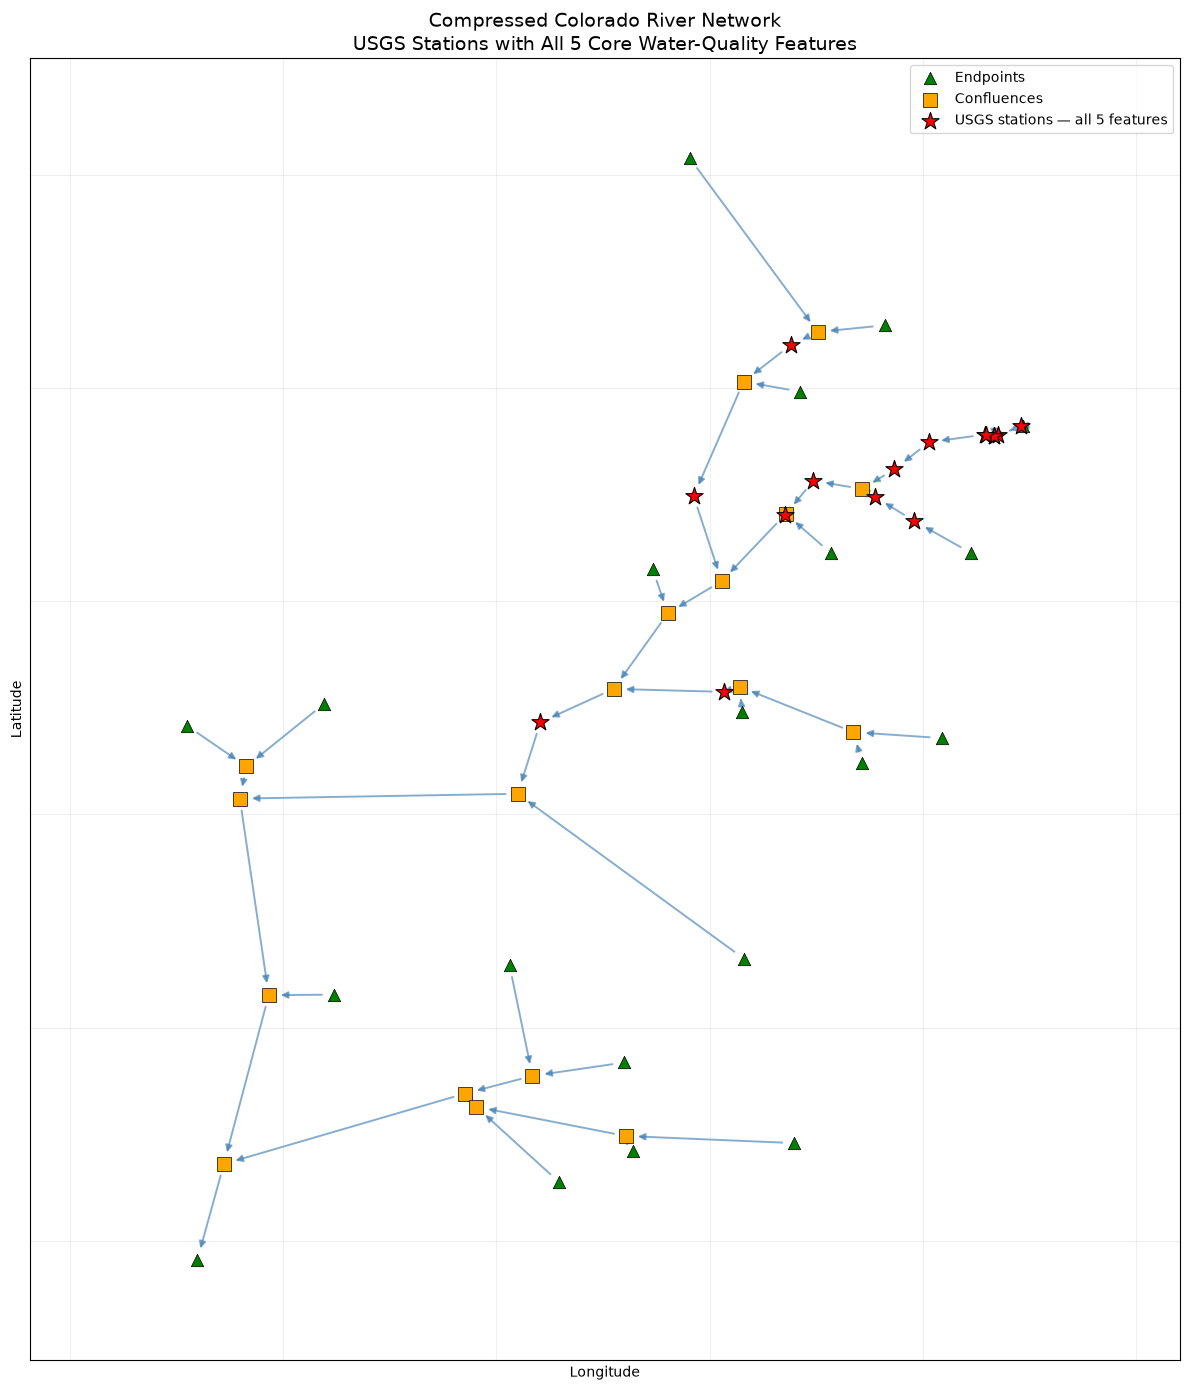

In [14]:
plt.figure(
    figsize=(12, 14)
)

# --------------------------------------------------
# River edges
# --------------------------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="steelblue",
    width=1.4,
    alpha=0.65,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=10,
    connectionstyle="arc3,rad=0.0"
)


# --------------------------------------------------
# Other retained nodes
# --------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=other_nodes,
    node_size=20,
    node_color="gray",
    alpha=0.7,
    label="Other retained nodes"
)


# --------------------------------------------------
# Endpoints
# --------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=endpoint_nodes,
    node_size=80,
    node_color="green",
    node_shape="^",
    edgecolors="black",
    linewidths=0.5,
    label="Endpoints"
)


# --------------------------------------------------
# Confluences
# --------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=confluence_nodes,
    node_size=90,
    node_color="orange",
    node_shape="s",
    edgecolors="black",
    linewidths=0.5,
    label="Confluences"
)


# --------------------------------------------------
# USGS stations with all 5 features
# --------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=station_nodes,
    node_size=170,
    node_color="red",
    node_shape="*",
    edgecolors="black",
    linewidths=0.8,
    label="USGS stations — all 5 features"
)


plt.title(
    "Compressed Colorado River Network\n"
    "USGS Stations with All 5 Core Water-Quality Features",
    fontsize=14
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(
    loc="best"
)

plt.grid(
    alpha=0.2
)

plt.axis("equal")

plt.tight_layout()

plt.show()

In [15]:
import pandas as pd

audit = pd.read_csv(
    "usgs_cleaning_audit.csv",
    low_memory=False
)

CORE_FEATURES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

# Only actual successfully downloaded data
usable = audit[
    audit["variable"].isin(CORE_FEATURES)
    &
    audit["status"].eq("ok")
    &
    (audit["hourly_nonnull"] > 0)
].copy()

actual_feature_counts = (
    usable
    .groupby("station_id")["variable"]
    .nunique()
    .reindex(
        audit["station_id"].astype(str).unique(),
        fill_value=0
    )
)

print("Actual feature counts:")
print(
    actual_feature_counts
    .value_counts()
    .sort_index(ascending=False)
)

print()

for n in range(5, 0, -1):
    print(
        f"{n}+ features:",
        (actual_feature_counts >= n).sum(),
        "stations"
    )

Actual feature counts:
variable
5    16
4     5
3     1
2     5
0     1
Name: count, dtype: int64

5+ features: 16 stations
4+ features: 21 stations
3+ features: 22 stations
2+ features: 27 stations
1+ features: 27 stations


In [16]:
MIN_COMPLETENESS = 50

usable_50 = audit[
    audit["variable"].isin(CORE_FEATURES)
    &
    audit["status"].eq("ok")
    &
    (audit["completeness_pct"] >= MIN_COMPLETENESS)
].copy()

feature_counts_50 = (
    usable_50
    .groupby("station_id")["variable"]
    .nunique()
)

print(
    f"Using >= {MIN_COMPLETENESS}% completeness:"
)

for n in range(5, 0, -1):
    print(
        f"{n}+ good features:",
        (feature_counts_50 >= n).sum(),
        "stations"
    )

Using >= 50% completeness:
5+ good features: 12 stations
4+ good features: 18 stations
3+ good features: 19 stations
2+ good features: 21 stations
1+ good features: 24 stations


In [17]:
for threshold in [
    30,
    50,
    60,
    70,
    80
]:

    good = audit[
        audit["variable"].isin(
            CORE_FEATURES
        )
        &
        audit["status"].eq("ok")
        &
        (
            audit["completeness_pct"]
            >= threshold
        )
    ]

    counts = (
        good
        .groupby(
            "station_id"
        )["variable"]
        .nunique()
    )

    print(
        f"\nCompleteness >= {threshold}%"
    )

    print(
        "5/5:",
        (counts >= 5).sum()
    )

    print(
        "4/5:",
        (counts >= 4).sum()
    )

    print(
        "3/5:",
        (counts >= 3).sum()
    )


Completeness >= 30%
5/5: 15
4/5: 19
3/5: 20

Completeness >= 50%
5/5: 12
4/5: 18
3/5: 19

Completeness >= 60%
5/5: 10
4/5: 16
3/5: 18

Completeness >= 70%
5/5: 5
4/5: 9
3/5: 12

Completeness >= 80%
5/5: 5
4/5: 8
3/5: 10


In [18]:
coverage = (
    usable
    .groupby("variable")[
        "station_id"
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print(coverage)

variable
Specific conductance    27
Water temperature       27
pH                      21
DO concentration        19
Turbidity               19
Name: station_id, dtype: int64


In [19]:
coverage_50 = (
    usable_50
    .groupby("variable")[
        "station_id"
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print(coverage_50)

variable
Specific conductance    23
Water temperature       22
DO concentration        18
pH                      18
Turbidity               13
Name: station_id, dtype: int64


In [23]:
from itertools import combinations
import pandas as pd

pd.set_option(
    "display.max_colwidth",
    None
)

station_feature_sets = (
    usable_50
    .groupby("station_id")["variable"]
    .apply(set)
)

results = []

for combo in combinations(
    CORE_FEATURES,
    4
):

    required = set(combo)

    stations = [
        station
        for station, features
        in station_feature_sets.items()
        if required.issubset(features)
    ]

    dropped_feature = (
        set(CORE_FEATURES)
        - required
    ).pop()

    results.append({
        "dropped_feature":
            dropped_feature,

        "required_features":
            " | ".join(combo),

        "stations":
            len(stations)
    })

four_feature_results = (
    pd.DataFrame(results)
    .sort_values(
        "stations",
        ascending=False
    )
    .reset_index(drop=True)
)

four_feature_results

,dropped_feature,required_features,stations
0,Turbidity,DO concentration | Water temperature | Specific conductance | pH,17
1,DO concentration,Water temperature | Specific conductance | Turbidity | pH,13
2,pH,DO concentration | Water temperature | Specific conductance | Turbidity,12
3,Specific conductance,DO concentration | Water temperature | Turbidity | pH,12
4,Water temperature,DO concentration | Specific conductance | Turbidity | pH,12


In [24]:
import pandas as pd
import numpy as np

CORE_FEATURES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

audit = pd.read_csv(
    "usgs_cleaning_audit.csv",
    low_memory=False
)

audit["station_id"] = (
    audit["station_id"]
    .astype(str)
    .str.strip()
)

# Require actual usable data
usable = audit[
    audit["variable"].isin(CORE_FEATURES)
    &
    audit["status"].eq("ok")
    &
    (audit["hourly_nonnull"] > 0)
].copy()

In [25]:
station_features = (
    usable
    .groupby("station_id")["variable"]
    .apply(set)
)

station_feature_count = (
    station_features
    .apply(len)
)

print(
    station_feature_count
    .value_counts()
    .sort_index(ascending=False)
)

print()

print(
    "5/5 stations:",
    (station_feature_count == 5).sum()
)

print(
    "Partial stations:",
    (station_feature_count < 5).sum()
)

variable
5    16
4     5
3     1
2     5
Name: count, dtype: int64

5/5 stations: 16
Partial stations: 11


In [26]:
import pickle
import networkx as nx

with open(
    "largest_river_component.pkl",
    "rb"
) as f:
    G = pickle.load(f)

print(
    G.number_of_nodes(),
    G.number_of_edges()
)

67401 67400


In [27]:
with open(
    "compressed_river_graph_28stations.pkl",
    "rb"
) as f:
    G28 = pickle.load(f)

station_to_node = {}

for node, data in G28.nodes(data=True):

    for station in data.get(
        "usgs_stations",
        []
    ):

        station_to_node[
            str(station["station_id"])
        ] = node

print(
    "Stations mapped:",
    len(station_to_node)
)

Stations mapped: 28


In [28]:
import math

def haversine_m(
    lat1,
    lon1,
    lat2,
    lon2
):

    R = 6371000

    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)

    dlat = lat2 - lat1
    dlon = math.radians(
        lon2 - lon1
    )

    a = (
        math.sin(dlat / 2) ** 2
        +
        math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    return (
        2
        * R
        * math.atan2(
            math.sqrt(a),
            math.sqrt(1 - a)
        )
    )


for u, v in G.edges():

    if "length_m" not in G.edges[u, v]:

        a = G.nodes[u]
        b = G.nodes[v]

        G.edges[u, v]["length_m"] = (
            haversine_m(
                a["latitude"],
                a["longitude"],
                b["latitude"],
                b["longitude"]
            )
        )

In [29]:
G_distance = G.to_undirected(
    as_view=True
)

station_ids = list(
    station_to_node.keys()
)

pair_rows = []

for i, station_a in enumerate(
    station_ids
):

    node_a = station_to_node[
        station_a
    ]

    lengths = (
        nx.single_source_dijkstra_path_length(
            G_distance,
            node_a,
            cutoff=20000,
            weight="length_m"
        )
    )

    for station_b in station_ids[
        i + 1:
    ]:

        node_b = station_to_node[
            station_b
        ]

        if node_b not in lengths:
            continue

        pair_rows.append({
            "station_a":
                station_a,

            "station_b":
                station_b,

            "network_distance_km":
                lengths[node_b] / 1000
        })


station_distances = pd.DataFrame(
    pair_rows
)

station_distances.sort_values(
    "network_distance_km"
).head(20)

,station_a,station_b,network_distance_km
6,USGS-393259107194801,USGS-09085000,0.092662
3,USGS-09085160,USGS-09085150,1.110918
5,USGS-393259107194801,USGS-09071750,5.172982
8,USGS-09071750,USGS-09085000,5.265645
10,USGS-09085000,USGS-09085150,8.357182
7,USGS-393259107194801,USGS-09085150,8.449844
2,USGS-09085160,USGS-09085000,9.468099
0,USGS-09085160,USGS-393259107194801,9.560762
9,USGS-09071750,USGS-09085150,13.622826
1,USGS-09085160,USGS-09071750,14.733744


In [30]:
for km in [
    1,
    2,
    5,
    10,
    20
]:

    print(
        f"<= {km} km:",
        (
            station_distances[
                "network_distance_km"
            ] <= km
        ).sum(),
        "pairs"
    )

<= 1 km: 1 pairs
<= 2 km: 2 pairs
<= 5 km: 2 pairs
<= 10 km: 8 pairs
<= 20 km: 11 pairs


In [31]:
def path_has_confluence(
    G,
    node_a,
    node_b
):

    U = G.to_undirected(
        as_view=True
    )

    try:

        path = nx.shortest_path(
            U,
            node_a,
            node_b,
            weight="length_m"
        )

    except nx.NetworkXNoPath:

        return True

    # Ignore the two station nodes
    interior = path[1:-1]

    return any(
        G.in_degree(node) >= 2
        for node in interior
    )

In [37]:
MERGE_DISTANCE_KM = 2

merge_candidates = (
    station_distances[
        station_distances[
            "network_distance_km"
        ]
        <= MERGE_DISTANCE_KM
    ]
    .copy()
)

merge_candidates[
    "crosses_confluence"
] = merge_candidates.apply(
    lambda row:
        path_has_confluence(
            G,
            station_to_node[
                row["station_a"]
            ],
            station_to_node[
                row["station_b"]
            ]
        ),
    axis=1
)

merge_candidates = (
    merge_candidates[
        ~merge_candidates[
            "crosses_confluence"
        ]
    ]
)

merge_candidates.sort_values(
    "network_distance_km"
)

,station_a,station_b,network_distance_km,crosses_confluence
6,USGS-393259107194801,USGS-09085000,0.092662,False
3,USGS-09085160,USGS-09085150,1.110918,False


In [38]:
station_cluster_graph = nx.Graph()

station_cluster_graph.add_nodes_from(
    station_ids
)

for _, row in merge_candidates.iterrows():

    station_cluster_graph.add_edge(
        row["station_a"],
        row["station_b"],
        distance_km=
            row["network_distance_km"]
    )

clusters = list(
    nx.connected_components(
        station_cluster_graph
    )
)

print(
    "Original stations:",
    len(station_ids)
)

print(
    "Station clusters:",
    len(clusters)
)

Original stations: 28
Station clusters: 26


In [39]:
for i, cluster in enumerate(
    clusters,
    start=1
):

    if len(cluster) > 1:

        print(
            f"\nCluster {i}:"
        )

        for station in sorted(
            cluster
        ):

            print(
                " ",
                station,
                station_feature_count.get(
                    station,
                    0
                ),
                "/ 5",
                station_features.get(
                    station,
                    set()
                )
            )


Cluster 1:
  USGS-09085150 5 / 5 {'DO concentration', 'Turbidity', 'Water temperature', 'Specific conductance', 'pH'}
  USGS-09085160 5 / 5 {'DO concentration', 'Turbidity', 'Water temperature', 'Specific conductance', 'pH'}

Cluster 13:
  USGS-09085000 5 / 5 {'DO concentration', 'Turbidity', 'Water temperature', 'Specific conductance', 'pH'}
  USGS-393259107194801 5 / 5 {'DO concentration', 'Turbidity', 'Water temperature', 'Specific conductance', 'pH'}


In [40]:
cluster_records = []

for cluster_id, cluster in enumerate(
    clusters,
    start=1
):

    combined_features = set()

    for station in cluster:

        combined_features |= (
            station_features.get(
                station,
                set()
            )
        )

    cluster_records.append({
        "cluster_id":
            cluster_id,

        "stations":
            sorted(cluster),

        "station_count":
            len(cluster),

        "features":
            sorted(
                combined_features
            ),

        "feature_count":
            len(
                combined_features
            ),

        "is_5of5":
            set(
                CORE_FEATURES
            ).issubset(
                combined_features
            )
    })


station_clusters = pd.DataFrame(
    cluster_records
)

station_clusters[
    [
        "cluster_id",
        "station_count",
        "feature_count",
        "is_5of5",
        "stations",
        "features"
    ]
]

,cluster_id,station_count,feature_count,is_5of5,stations,features
0,1,2,5,True,"[USGS-09085150, USGS-09085160]","[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
1,2,1,5,True,[USGS-09144250],"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
2,3,1,5,True,[USGS-09180500],"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
3,4,1,3,False,[USGS-09106485],"[DO concentration, Specific conductance, Water temperature]"
4,5,1,5,True,[USGS-09163500],"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
5,6,1,5,True,[USGS-09261000],"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
6,7,1,2,False,[USGS-09234500],"[Specific conductance, Water temperature]"
7,8,1,5,True,[USGS-09095500],"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]"
8,9,1,2,False,[USGS-09306500],"[Specific conductance, Water temperature]"
9,10,1,2,False,[USGS-09180000],"[Specific conductance, Water temperature]"


In [41]:
station_quality = (
    usable
    .groupby("station_id")[
        "completeness_pct"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)

station_quality.head()

station_id
USGS-09106485    99.946978
USGS-09085150    98.164803
USGS-09315000    93.937457
USGS-09180500    93.754138
USGS-09379500    93.671955
Name: completeness_pct, dtype: float64

In [42]:
candidate_10km = (
    station_distances[
        station_distances[
            "network_distance_km"
        ]
        <= 10
    ]
    .copy()
)

rows = []

for _, row in candidate_10km.iterrows():

    a = row["station_a"]
    b = row["station_b"]

    features_a = station_features.get(
        a,
        set()
    )

    features_b = station_features.get(
        b,
        set()
    )

    combined = (
        features_a
        | features_b
    )

    gain_a = (
        combined - features_a
    )

    gain_b = (
        combined - features_b
    )

    rows.append({
        "station_a":
            a,

        "station_b":
            b,

        "distance_km":
            row[
                "network_distance_km"
            ],

        "a_features":
            len(features_a),

        "b_features":
            len(features_b),

        "combined_features":
            len(combined),

        "new_for_a":
            ", ".join(
                sorted(gain_a)
            ),

        "new_for_b":
            ", ".join(
                sorted(gain_b)
            ),

        "becomes_5of5":
            len(combined) == 5
    })


complement_table = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "becomes_5of5",
            "combined_features",
            "distance_km"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

pd.set_option(
    "display.max_colwidth",
    None
)

complement_table

,station_a,station_b,distance_km,a_features,b_features,combined_features,new_for_a,new_for_b,becomes_5of5
4,USGS-393259107194801,USGS-09085000,0.092662,5,5,5,,,True
2,USGS-09085160,USGS-09085150,1.110918,5,5,5,,,True
3,USGS-393259107194801,USGS-09071750,5.172982,5,5,5,,,True
6,USGS-09071750,USGS-09085000,5.265645,5,5,5,,,True
7,USGS-09085000,USGS-09085150,8.357182,5,5,5,,,True
5,USGS-393259107194801,USGS-09085150,8.449844,5,5,5,,,True
1,USGS-09085160,USGS-09085000,9.468099,5,5,5,,,True
0,USGS-09085160,USGS-393259107194801,9.560762,5,5,5,,,True


In [43]:
partial_ids = set(
    station_feature_count[
        station_feature_count < 5
    ].index.astype(str)
)

full_ids = set(
    station_feature_count[
        station_feature_count == 5
    ].index.astype(str)
)

print("5/5 stations:", len(full_ids))
print("Partial stations:", len(partial_ids))

5/5 stations: 16
Partial stations: 11


In [44]:
partial_pairs = station_distances[
    station_distances["station_a"].isin(partial_ids)
    &
    station_distances["station_b"].isin(partial_ids)
].copy()

partial_pairs = partial_pairs.sort_values(
    "network_distance_km"
)

partial_pairs.head(20)

,station_a,station_b,network_distance_km


In [45]:
partial_full_pairs = station_distances[
    (
        station_distances["station_a"].isin(partial_ids)
        &
        station_distances["station_b"].isin(full_ids)
    )
    |
    (
        station_distances["station_b"].isin(partial_ids)
        &
        station_distances["station_a"].isin(full_ids)
    )
].copy()

partial_full_pairs = partial_full_pairs.sort_values(
    "network_distance_km"
)

partial_full_pairs.head(20)

,station_a,station_b,network_distance_km
4,USGS-09180500,USGS-09180000,18.521485


In [46]:
rows = []

for _, row in partial_pairs.iterrows():

    a = row["station_a"]
    b = row["station_b"]

    fa = station_features.get(a, set())
    fb = station_features.get(b, set())

    combined = fa | fb

    rows.append({
        "station_a": a,
        "station_b": b,
        "distance_km":
            row["network_distance_km"],

        "a_count":
            len(fa),

        "b_count":
            len(fb),

        "combined_count":
            len(combined),

        "a_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES) - fa
                )
            ),

        "b_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES) - fb
                )
            ),

        "combined_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES)
                    - combined
                )
            ),

        "becomes_5of5":
            len(combined) == 5
    })


partial_complement = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "becomes_5of5",
            "combined_count",
            "distance_km"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

pd.set_option(
    "display.max_colwidth",
    None
)

partial_complement.head(30)

KeyError: 'becomes_5of5'

In [47]:
cutoff=20000

In [48]:
print("Partial stations:", len(partial_ids))
print("Partial-partial pairs currently found:", len(partial_pairs))

Partial stations: 11
Partial-partial pairs currently found: 0


In [49]:
G_distance = G.to_undirected(
    as_view=True
)

station_ids = list(
    station_to_node.keys()
)

pair_rows = []

for i, station_a in enumerate(
    station_ids
):

    print(
        f"{i+1}/{len(station_ids)}",
        station_a
    )

    node_a = station_to_node[
        station_a
    ]

    # No cutoff this time
    lengths = (
        nx.single_source_dijkstra_path_length(
            G_distance,
            node_a,
            weight="length_m"
        )
    )

    for station_b in station_ids[
        i + 1:
    ]:

        node_b = station_to_node[
            station_b
        ]

        if node_b not in lengths:
            continue

        pair_rows.append({
            "station_a":
                station_a,

            "station_b":
                station_b,

            "network_distance_km":
                lengths[node_b] / 1000
        })


station_distances_full = (
    pd.DataFrame(pair_rows)
)

print(
    "Station pairs:",
    len(station_distances_full)
)

print(
    "Maximum distance:",
    station_distances_full[
        "network_distance_km"
    ].max(),
    "km"
)

1/28 USGS-09085160
2/28 USGS-09144250
3/28 USGS-09180500
4/28 USGS-09106485
5/28 USGS-09163500
6/28 USGS-09261000
7/28 USGS-09234500
8/28 USGS-09095500
9/28 USGS-09306500
10/28 USGS-09180000
11/28 USGS-09365000
12/28 USGS-09217000
13/28 USGS-393259107194801
14/28 USGS-09315000
15/28 USGS-09071750
16/28 USGS-09328960
17/28 USGS-09070500
18/28 USGS-09510000
19/28 USGS-09152500
20/28 USGS-09368000
21/28 USGS-09092570
22/28 USGS-09085000
23/28 USGS-09380000
24/28 USGS-09429490
25/28 USGS-09379500
26/28 USGS-09371010
27/28 USGS-09085150
28/28 USGS-09404200
Station pairs: 378
Maximum distance: 2772.804913322191 km


In [50]:
partial_pairs = (
    station_distances_full[
        station_distances_full[
            "station_a"
        ].isin(partial_ids)
        &
        station_distances_full[
            "station_b"
        ].isin(partial_ids)
    ]
    .copy()
    .sort_values(
        "network_distance_km"
    )
)

print(
    "Partial-partial pairs:",
    len(partial_pairs)
)

partial_pairs.head(20)

Partial-partial pairs: 55


,station_a,station_b,network_distance_km
347,USGS-09368000,USGS-09371010,59.450336
233,USGS-09365000,USGS-09368000,59.665809
239,USGS-09365000,USGS-09371010,119.116145
151,USGS-09234500,USGS-09217000,144.343692
83,USGS-09106485,USGS-09180000,148.800137
212,USGS-09180000,USGS-09328960,215.779437
89,USGS-09106485,USGS-09328960,331.258820
148,USGS-09234500,USGS-09306500,373.021638
328,USGS-09510000,USGS-09429490,469.695801
190,USGS-09306500,USGS-09217000,517.365330


In [51]:
rows = []

for _, row in partial_pairs.iterrows():

    a = row["station_a"]
    b = row["station_b"]

    fa = station_features.get(
        a,
        set()
    )

    fb = station_features.get(
        b,
        set()
    )

    combined = fa | fb

    rows.append({
        "station_a":
            a,

        "station_b":
            b,

        "distance_km":
            row[
                "network_distance_km"
            ],

        "a_count":
            len(fa),

        "b_count":
            len(fb),

        "combined_count":
            len(combined),

        "a_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES)
                    - fa
                )
            ),

        "b_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES)
                    - fb
                )
            ),

        "combined_missing":
            ", ".join(
                sorted(
                    set(CORE_FEATURES)
                    - combined
                )
            ),

        "becomes_5of5":
            set(CORE_FEATURES)
            .issubset(combined)
    })


if rows:

    partial_complement = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "becomes_5of5",
                "combined_count",
                "distance_km"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    pd.set_option(
        "display.max_colwidth",
        None
    )

    display(
        partial_complement.head(30)
    )

else:

    print(
        "No partial-partial station pairs found."
    )

,station_a,station_b,distance_km,a_count,b_count,combined_count,a_missing,b_missing,combined_missing,becomes_5of5
0,USGS-09106485,USGS-09371010,858.919428,3,4,5,"Turbidity, pH",DO concentration,,True
1,USGS-09106485,USGS-09368000,918.369764,3,4,5,"Turbidity, pH",DO concentration,,True
2,USGS-09106485,USGS-09365000,978.035572,3,4,5,"Turbidity, pH",DO concentration,,True
3,USGS-09429490,USGS-09371010,1552.323506,4,4,5,Turbidity,DO concentration,,True
4,USGS-09368000,USGS-09429490,1611.773842,4,4,5,DO concentration,Turbidity,,True
5,USGS-09365000,USGS-09429490,1671.439651,4,4,5,DO concentration,Turbidity,,True
6,USGS-09510000,USGS-09371010,2022.019307,4,4,5,Turbidity,DO concentration,,True
7,USGS-09510000,USGS-09368000,2081.469643,4,4,5,Turbidity,DO concentration,,True
8,USGS-09365000,USGS-09510000,2141.135452,4,4,5,DO concentration,Turbidity,,True
9,USGS-09368000,USGS-09371010,59.450336,4,4,4,DO concentration,DO concentration,DO concentration,False


In [52]:
station_role_rows = []

for station_id in station_to_node:

    features = station_features.get(
        station_id,
        set()
    )

    count = len(features)

    if count == 5:
        role = "full_5of5"

    elif count >= 3:
        role = "partial_wq"

    elif count > 0:
        role = "limited_wq"

    else:
        role = "no_core_wq"

    station_role_rows.append({
        "station_id": station_id,
        "feature_count": count,
        "features": sorted(features),
        "missing_features": sorted(
            set(CORE_FEATURES) - features
        ),
        "role": role
    })


station_roles = pd.DataFrame(
    station_role_rows
)

station_roles.sort_values(
    [
        "feature_count",
        "station_id"
    ],
    ascending=[
        False,
        True
    ]
)

,station_id,feature_count,features,missing_features,role
16,USGS-09070500,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
14,USGS-09071750,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
21,USGS-09085000,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
26,USGS-09085150,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
0,USGS-09085160,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
20,USGS-09092570,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
7,USGS-09095500,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
1,USGS-09144250,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
18,USGS-09152500,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5
4,USGS-09163500,5,"[DO concentration, Specific conductance, Turbidity, Water temperature, pH]",[],full_5of5


In [53]:
print(
    station_roles[
        "role"
    ].value_counts()
)

role
full_5of5     16
partial_wq     6
limited_wq     5
no_core_wq     1
Name: count, dtype: int64


In [54]:
MERGE_DISTANCE_KM = 2

close_pairs = station_distances_full[
    station_distances_full[
        "network_distance_km"
    ] <= MERGE_DISTANCE_KM
].copy()

In [55]:
close_pairs[
    "crosses_confluence"
] = close_pairs.apply(
    lambda row:
        path_has_confluence(
            G,
            station_to_node[
                row["station_a"]
            ],
            station_to_node[
                row["station_b"]
            ]
        ),
    axis=1
)

close_pairs = close_pairs[
    ~close_pairs[
        "crosses_confluence"
    ]
].copy()

close_pairs[
    [
        "station_a",
        "station_b",
        "network_distance_km"
    ]
]

,station_a,station_b,network_distance_km
25,USGS-09085160,USGS-09085150,1.110918
266,USGS-393259107194801,USGS-09085000,0.092662


In [56]:
cluster_graph = nx.Graph()

cluster_graph.add_nodes_from(
    station_to_node.keys()
)

for _, row in close_pairs.iterrows():

    cluster_graph.add_edge(
        row["station_a"],
        row["station_b"]
    )

station_clusters = list(
    nx.connected_components(
        cluster_graph
    )
)

station_to_cluster = {}

for cluster_id, cluster in enumerate(
    station_clusters,
    start=1
):

    for station in cluster:

        station_to_cluster[
            station
        ] = cluster_id


station_roles[
    "cluster_id"
] = (
    station_roles[
        "station_id"
    ].map(
        station_to_cluster
    )
)

print(
    "Raw stations:",
    len(station_roles)
)

print(
    "Effective station locations:",
    station_roles[
        "cluster_id"
    ].nunique()
)

Raw stations: 28
Effective station locations: 26


In [57]:
import numpy as np
import pandas as pd
import networkx as nx

CORE_FEATURES = [
    "DO concentration",
    "Water temperature",
    "Specific conductance",
    "Turbidity",
    "pH"
]

MERGE_DISTANCE_KM = 2.0

In [58]:
close_pairs = station_distances_full[
    station_distances_full[
        "network_distance_km"
    ] <= MERGE_DISTANCE_KM
].copy()

close_pairs[
    "crosses_confluence"
] = close_pairs.apply(
    lambda row: path_has_confluence(
        G,
        station_to_node[row["station_a"]],
        station_to_node[row["station_b"]]
    ),
    axis=1
)

close_pairs = close_pairs[
    ~close_pairs["crosses_confluence"]
].copy()

display(
    close_pairs[
        [
            "station_a",
            "station_b",
            "network_distance_km"
        ]
    ]
)

,station_a,station_b,network_distance_km
25,USGS-09085160,USGS-09085150,1.110918
266,USGS-393259107194801,USGS-09085000,0.092662


In [59]:
cluster_graph = nx.Graph()

cluster_graph.add_nodes_from(
    station_to_node.keys()
)

for _, row in close_pairs.iterrows():

    cluster_graph.add_edge(
        row["station_a"],
        row["station_b"]
    )

clusters = list(
    nx.connected_components(
        cluster_graph
    )
)

print("Raw WQ stations:", len(station_to_node))
print("Effective WQ locations:", len(clusters))

Raw WQ stations: 28
Effective WQ locations: 26


In [60]:
core_audit = audit[
    audit["variable"].isin(
        CORE_FEATURES
    )
    &
    audit["status"].eq("ok")
].copy()

station_quality = (
    core_audit
    .groupby("station_id")[
        "completeness_pct"
    ]
    .mean()
    .to_dict()
)

In [61]:
cluster_rows = []

for cluster_id, members in enumerate(
    clusters,
    start=1
):

    members = sorted(
        str(x)
        for x in members
    )

    combined_features = set()

    for station in members:

        combined_features |= (
            station_features.get(
                station,
                set()
            )
        )

    anchor_station = max(
        members,
        key=lambda station:
            station_quality.get(
                station,
                0
            )
    )

    anchor_node = station_to_node[
        anchor_station
    ]

    cluster_rows.append({
        "cluster_id":
            cluster_id,

        "anchor_station":
            anchor_station,

        "anchor_node":
            anchor_node,

        "member_stations":
            members,

        "member_count":
            len(members),

        "features":
            sorted(
                combined_features
            ),

        "feature_count":
            len(
                combined_features
            ),

        "is_full_5of5":
            set(CORE_FEATURES)
            .issubset(
                combined_features
            )
    })


cluster_table = pd.DataFrame(
    cluster_rows
)

display(
    cluster_table[
        [
            "cluster_id",
            "anchor_station",
            "member_count",
            "feature_count",
            "is_full_5of5",
            "member_stations"
        ]
    ]
)

,cluster_id,anchor_station,member_count,feature_count,is_full_5of5,member_stations
0,1,USGS-09085150,2,5,True,"[USGS-09085150, USGS-09085160]"
1,2,USGS-09144250,1,5,True,[USGS-09144250]
2,3,USGS-09180500,1,5,True,[USGS-09180500]
3,4,USGS-09106485,1,3,False,[USGS-09106485]
4,5,USGS-09163500,1,5,True,[USGS-09163500]
5,6,USGS-09261000,1,5,True,[USGS-09261000]
6,7,USGS-09234500,1,2,False,[USGS-09234500]
7,8,USGS-09095500,1,5,True,[USGS-09095500]
8,9,USGS-09306500,1,2,False,[USGS-09306500]
9,10,USGS-09180000,1,2,False,[USGS-09180000]


In [62]:
TEST_FRACTION = 0.25
RANDOM_SEED = 42

full_cluster_ids = (
    cluster_table.loc[
        cluster_table[
            "is_full_5of5"
        ],
        "cluster_id"
    ]
    .tolist()
)

rng = np.random.default_rng(
    RANDOM_SEED
)

n_full = len(
    full_cluster_ids
)

n_test = max(
    1,
    int(
        round(
            n_full
            * TEST_FRACTION
        )
    )
)

# If we have enough full stations,
# keep at least two for training.
if n_full >= 4:
    n_test = min(
        n_test,
        n_full - 2
    )

full_test_clusters = set(
    rng.choice(
        full_cluster_ids,
        size=n_test,
        replace=False
    ).tolist()
)

print("Full 5/5 effective stations:", n_full)
print("Full stations used for test:", n_test)

Full 5/5 effective stations: 14
Full stations used for test: 4


In [63]:
def assign_role(row):

    if row["is_full_5of5"]:

        if (
            row["cluster_id"]
            in full_test_clusters
        ):
            return "test_full"

        return "train"

    return "test_partial"


cluster_table[
    "ml_role"
] = cluster_table.apply(
    assign_role,
    axis=1
)

print(
    cluster_table[
        "ml_role"
    ].value_counts()
)

ml_role
test_partial    12
train           10
test_full        4
Name: count, dtype: int64


In [64]:
display(
    cluster_table[
        [
            "cluster_id",
            "anchor_station",
            "member_stations",
            "feature_count",
            "ml_role"
        ]
    ]
    .sort_values(
        [
            "ml_role",
            "cluster_id"
        ]
    )
)

,cluster_id,anchor_station,member_stations,feature_count,ml_role
0,1,USGS-09085150,"[USGS-09085150, USGS-09085160]",5,test_full
12,13,USGS-09085000,"[USGS-09085000, USGS-393259107194801]",5,test_full
14,15,USGS-09071750,[USGS-09071750],5,test_full
16,17,USGS-09070500,[USGS-09070500],5,test_full
3,4,USGS-09106485,[USGS-09106485],3,test_partial
6,7,USGS-09234500,[USGS-09234500],2,test_partial
8,9,USGS-09306500,[USGS-09306500],2,test_partial
9,10,USGS-09180000,[USGS-09180000],2,test_partial
10,11,USGS-09365000,[USGS-09365000],4,test_partial
11,12,USGS-09217000,[USGS-09217000],2,test_partial


In [65]:
import pickle

with open(
    "largest_river_component.pkl",
    "rb"
) as f:

    G_master = pickle.load(f)

print(
    G_master.number_of_nodes(),
    G_master.number_of_edges()
)

67401 67400


In [66]:
for node in G_master.nodes():

    data = G_master.nodes[node]

    for field in [
        "stations",
        "station_count",
        "station_ids",
        "station_id",
        "usgs_stations",
        "usgs_station_count",
        "usgs_clusters",
        "support_gauges",
        "support_gauge_count"
    ]:
        data.pop(
            field,
            None
        )

    data[
        "usgs_clusters"
    ] = []

    data[
        "usgs_station_count"
    ] = 0

    data[
        "support_gauges"
    ] = []

    data[
        "support_gauge_count"
    ] = 0

In [67]:
for _, row in cluster_table.iterrows():

    node = int(
        row["anchor_node"]
    )

    cluster_data = {
        "cluster_id":
            int(
                row["cluster_id"]
            ),

        "anchor_station":
            row["anchor_station"],

        "member_stations":
            list(
                row["member_stations"]
            ),

        "member_count":
            int(
                row["member_count"]
            ),

        "features":
            list(
                row["features"]
            ),

        "feature_count":
            int(
                row["feature_count"]
            ),

        "is_full_5of5":
            bool(
                row["is_full_5of5"]
            ),

        "ml_role":
            row["ml_role"]
    }

    G_master.nodes[
        node
    ][
        "usgs_clusters"
    ].append(
        cluster_data
    )

    G_master.nodes[
        node
    ][
        "usgs_station_count"
    ] += 1

In [68]:
print(
    "Effective WQ locations attached:",
    sum(
        data.get(
            "usgs_station_count",
            0
        )
        for _, data
        in G_master.nodes(
            data=True
        )
    )
)

Effective WQ locations attached: 26


In [69]:
len(cluster_table)

26

In [70]:
if "support_node_matches" in globals():

    support_id_col = (
        "monitoring_location_id"
        if "monitoring_location_id"
        in support_node_matches.columns
        else "station_id"
    )

    support_subset = (
        support_node_matches
        .drop_duplicates(
            subset=support_id_col
        )
        .copy()
    )

    for _, row in support_subset.iterrows():

        gauge_id = str(
            row[
                support_id_col
            ]
        )

        node = int(
            row[
                "river_node"
            ]
        )

        G_master.nodes[
            node
        ][
            "support_gauges"
        ].append({
            "station_id":
                gauge_id,

            "role":
                "hydrology_support"
        })

        G_master.nodes[
            node
        ][
            "support_gauge_count"
        ] += 1

    print(
        "Support gauges attached:",
        sum(
            d.get(
                "support_gauge_count",
                0
            )
            for _, d
            in G_master.nodes(
                data=True
            )
        )
    )

else:

    print(
        "support_node_matches is not loaded."
    )

support_node_matches is not loaded.


In [71]:
print("master_station_table loaded:",
      "master_station_table" in globals())

if "master_station_table" in globals():
    print(master_station_table.columns.tolist())

master_station_table loaded: False


In [72]:
import pandas as pd

master_station_table = pd.read_csv(
    "master_wq_station_table.csv",
    low_memory=False
)

cols = [
    c for c in [
        "wq_station",
        "selected_support_gauge",
        "support_direction",
        "support_distance_km"
    ]
    if c in master_station_table.columns
]

display(
    master_station_table[cols].head(30)
)

,wq_station,selected_support_gauge,support_direction,support_distance_km
0,USGS-09070500,NaN,NaN,NaN
1,USGS-09071750,USGS-09085100,downstream,6.414474
2,USGS-09085000,NaN,NaN,NaN
3,USGS-09085150,USGS-09085500,downstream,4.206340
4,USGS-09085160,USGS-09085500,downstream,3.095422
5,USGS-09092570,NaN,NaN,NaN
6,USGS-09095500,NaN,NaN,NaN
7,USGS-09106485,NaN,NaN,NaN
8,USGS-09144250,NaN,NaN,NaN
9,USGS-09152500,NaN,NaN,NaN


In [73]:
support_ids = (
    master_station_table[
        "selected_support_gauge"
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

print(
    "Unique support gauges:",
    len(support_ids)
)

print(support_ids)

Unique support gauges: 3
['USGS-09085100', 'USGS-09085500', 'USGS-09523000']


In [75]:
import requests
import pandas as pd

USGS_API_KEY = "Wg8C6eEgjnC9TdHHYwnA1lBZXdJNVpYk5SDcH5Dr"

MONITORING_URL = (
    "https://api.waterdata.usgs.gov/"
    "ogcapi/v1/collections/"
    "monitoring-locations/items"
)

query = {
    "op": "in",
    "args": [
        {
            "property": "id"
        },
        support_ids
    ]
}

response = requests.post(
    MONITORING_URL,
    params={
        "f": "json",
        "limit": 100
    },
    headers={
        "Content-Type":
            "application/query-cql-json",
        "X-Api-Key":
            USGS_API_KEY
    },
    json=query,
    timeout=120
)

response.raise_for_status()

payload = response.json()

support_rows = [
    feature["properties"]
    for feature in payload.get(
        "features",
        []
    )
]

support_metadata = pd.DataFrame(
    support_rows
)

print(
    "Support gauges returned:",
    len(support_metadata)
)

print(
    support_metadata.columns.tolist()
)

Support gauges returned: 3
['id', 'agency_code', 'agency_name', 'monitoring_location_number', 'monitoring_location_name', 'district_code', 'country_code', 'country_name', 'state_code', 'state_name', 'county_code', 'county_name', 'minor_civil_division_code', 'site_type_code', 'site_type', 'hydrologic_unit_code', 'basin_code', 'altitude', 'altitude_accuracy', 'altitude_method_code', 'altitude_method_name', 'vertical_datum', 'vertical_datum_name', 'horizontal_positional_accuracy_code', 'horizontal_positional_accuracy', 'horizontal_position_method_code', 'horizontal_position_method_name', 'original_horizontal_datum', 'original_horizontal_datum_name', 'drainage_area', 'contributing_drainage_area', 'time_zone_abbreviation', 'uses_daylight_savings', 'construction_date', 'aquifer_code', 'national_aquifer_code', 'aquifer_type_code', 'well_constructed_depth', 'hole_constructed_depth', 'depth_source_code', 'revision_note', 'revision_created', 'revision_modified']


In [76]:
display(
    support_metadata
)

,id,agency_code,agency_name,monitoring_location_number,monitoring_location_name,district_code,country_code,country_name,state_code,state_name,...,construction_date,aquifer_code,national_aquifer_code,aquifer_type_code,well_constructed_depth,hole_constructed_depth,depth_source_code,revision_note,revision_created,revision_modified
0,USGS-09085100,USGS,U.S. Geological Survey,09085100,"COLORADO RIVER BELOW GLENWOOD SPRINGS, CO",08,US,United States of America,08,Colorado,...,None,None,None,None,None,None,None,WDR-US-2011: Drainage area.,2017-11-13T06:00:00+00:00,None
1,USGS-09085500,USGS,U.S. Geological Survey,09085500,"CANYON CREEK NEAR NEW CASTLE, CO.",08,US,United States of America,08,Colorado,...,None,None,None,None,None,None,None,NaN,NaN,None
2,USGS-09523000,USGS,U.S. Geological Survey,09523000,"ALL-AMERICAN CANAL NR IMPERIAL DAM, CA-AZ",04,US,United States of America,06,California,...,None,None,None,None,None,None,None,NaN,NaN,None


In [77]:
coordinate_cols = [
    c
    for c in support_metadata.columns
    if any(
        word in c.lower()
        for word in [
            "lat",
            "lon",
            "long"
        ]
    )
]

print(
    coordinate_cols
)

[]


In [79]:
support_rows = []

for feature in payload.get(
    "features",
    []
):

    props = feature.get(
        "properties",
        {}
    ).copy()

    geometry = feature.get(
        "geometry"
    )

    if (
        geometry
        and geometry.get("type") == "Point"
        and geometry.get("coordinates")
    ):

        longitude, latitude = (
            geometry["coordinates"][:2]
        )

        props["longitude"] = longitude
        props["latitude"] = latitude

    support_rows.append(
        props
    )


support_metadata = pd.DataFrame(
    support_rows
)

print(
    "Support gauges returned:",
    len(support_metadata)
)

display(
    support_metadata[
        [
            "id",
            "longitude",
            "latitude"
        ]
    ]
)

Support gauges returned: 3


,id,longitude,latitude
0,USGS-09085100,-107.337554,39.554982
1,USGS-09085500,-107.447925,39.574536
2,USGS-09523000,-114.480464,32.870994


In [80]:
import geopandas as gpd

support_points = (
    support_metadata[
        support_metadata["id"]
        .astype(str)
        .isin(support_ids)
    ]
    .copy()
)

support_points_gdf = (
    gpd.GeoDataFrame(
        support_points,
        geometry=gpd.points_from_xy(
            support_points[
                "longitude"
            ],
            support_points[
                "latitude"
            ]
        ),
        crs="EPSG:4326"
    )
)

print(
    "Support points:",
    len(support_points_gdf)
)

Support points: 3


In [81]:
import geopandas as gpd

support_points_gdf = (
    gpd.GeoDataFrame(
        support_metadata.copy(),

        geometry=gpd.points_from_xy(
            support_metadata[
                "longitude"
            ],
            support_metadata[
                "latitude"
            ]
        ),

        crs="EPSG:4326"
    )
)

print(
    "Support points:",
    len(support_points_gdf)
)

display(
    support_points_gdf[
        [
            "id",
            "longitude",
            "latitude",
            "geometry"
        ]
    ]
)

Support points: 3


,id,longitude,latitude,geometry
0,USGS-09085100,-107.337554,39.554982,POINT (-107.33755 39.55498)
1,USGS-09085500,-107.447925,39.574536,POINT (-107.44792 39.57454)
2,USGS-09523000,-114.480464,32.870994,POINT (-114.48046 32.87099)


In [82]:
from shapely.geometry import Point

river_records = []

for node, data in G_master.nodes(
    data=True
):

    river_records.append({
        "river_node": node,

        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })


river_nodes_gdf = (
    gpd.GeoDataFrame(
        river_records,
        geometry="geometry",
        crs="EPSG:4326"
    )
)

PROJECTED_CRS = "EPSG:5070"

river_nodes_m = (
    river_nodes_gdf
    .to_crs(PROJECTED_CRS)
)

support_points_m = (
    support_points_gdf
    .to_crs(PROJECTED_CRS)
)

support_node_matches = (
    gpd.sjoin_nearest(
        support_points_m,
        river_nodes_m,
        how="left",
        distance_col=
            "distance_to_node_m"
    )
)

display(
    support_node_matches[
        [
            "id",
            "river_node",
            "distance_to_node_m"
        ]
    ]
)

,id,river_node,distance_to_node_m
0,USGS-09085100,83102734,5.023746
1,USGS-09085500,82757580,114.837545
2,USGS-09523000,203417183,38.783713


In [83]:
for _, row in (
    support_node_matches
    .drop_duplicates(subset="id")
    .iterrows()
):

    gauge_id = str(
        row["id"]
    )

    node = int(
        row["river_node"]
    )

    used_by = (
        master_station_table.loc[
            master_station_table[
                "selected_support_gauge"
            ].astype(str)
            == gauge_id,
            "wq_station"
        ]
        .astype(str)
        .tolist()
    )

    gauge_info = {
        "station_id":
            gauge_id,

        "role":
            "hydrology_support",

        "used_by_wq_stations":
            used_by,

        "distance_to_node_m":
            float(
                row[
                    "distance_to_node_m"
                ]
            )
    }

    G_master.nodes[
        node
    ][
        "support_gauges"
    ].append(
        gauge_info
    )

    G_master.nodes[
        node
    ][
        "support_gauge_count"
    ] += 1

In [84]:
print(
    "Support gauges attached:",
    sum(
        data.get(
            "support_gauge_count",
            0
        )
        for _, data
        in G_master.nodes(
            data=True
        )
    )
)

Support gauges attached: 3


In [86]:
import math
import networkx as nx

def compress_master_graph(G):

    keep_nodes = set()

    # --------------------------------------------------
    # 1. Decide which nodes must remain
    # --------------------------------------------------

    for node, data in G.nodes(data=True):

        has_wq = (
            data.get(
                "usgs_station_count",
                0
            ) > 0
        )

        has_support = (
            data.get(
                "support_gauge_count",
                0
            ) > 0
        )

        simple_node = (
            G.in_degree(node) == 1
            and
            G.out_degree(node) == 1
        )

        # Keep:
        # - WQ station nodes
        # - hydrology support nodes
        # - endpoints
        # - confluences / branches
        if (
            has_wq
            or has_support
            or not simple_node
        ):
            keep_nodes.add(node)

    print(
        "Original nodes:",
        G.number_of_nodes()
    )

    print(
        "Nodes retained:",
        len(keep_nodes)
    )

    print(
        "Nodes compressed away:",
        G.number_of_nodes()
        - len(keep_nodes)
    )


    # --------------------------------------------------
    # 2. Haversine distance
    # --------------------------------------------------

    def distance_m(a, b):

        da = G.nodes[a]
        db = G.nodes[b]

        lat1 = math.radians(
            da["latitude"]
        )

        lon1 = math.radians(
            da["longitude"]
        )

        lat2 = math.radians(
            db["latitude"]
        )

        lon2 = math.radians(
            db["longitude"]
        )

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        h = (
            math.sin(
                dlat / 2
            ) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(
                dlon / 2
            ) ** 2
        )

        return (
            6371000
            * 2
            * math.atan2(
                math.sqrt(h),
                math.sqrt(1 - h)
            )
        )


    # --------------------------------------------------
    # 3. Create compressed directed graph
    # --------------------------------------------------

    C = nx.DiGraph()

    C.graph.update(
        G.graph
    )


    # Copy retained node attributes
    for node in keep_nodes:

        C.add_node(
            node,
            **G.nodes[node]
        )


    # --------------------------------------------------
    # 4. Collapse chains between retained nodes
    # --------------------------------------------------

    for start in keep_nodes:

        for next_node in G.successors(
            start
        ):

            path = [
                start,
                next_node
            ]

            current = next_node


            while current not in keep_nodes:

                successors = list(
                    G.successors(
                        current
                    )
                )

                if len(successors) != 1:
                    break

                nxt = successors[0]

                # Safety against cycles
                if nxt in path:
                    break

                path.append(
                    nxt
                )

                current = nxt


            end = path[-1]


            if end not in keep_nodes:
                continue


            total_length = sum(
                distance_m(
                    u,
                    v
                )

                for u, v
                in zip(
                    path[:-1],
                    path[1:]
                )
            )


            C.add_edge(
                start,
                end,

                weight=
                    total_length,

                length_m=
                    total_length,

                original_edge_count=
                    len(path) - 1,

                compressed_node_count=
                    max(
                        len(path) - 2,
                        0
                    ),

                original_path=
                    path
            )


    return C

In [87]:
G_master_compressed = (
    compress_master_graph(
        G_master
    )
)

print(
    "Nodes:",
    G_master_compressed.number_of_nodes()
)

print(
    "Edges:",
    G_master_compressed.number_of_edges()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_master_compressed
    )
)

print(
    "Effective WQ locations:",
    sum(
        d.get(
            "usgs_station_count",
            0
        )
        for _, d
        in G_master_compressed.nodes(
            data=True
        )
    )
)

print(
    "Support gauges:",
    sum(
        d.get(
            "support_gauge_count",
            0
        )
        for _, d
        in G_master_compressed.nodes(
            data=True
        )
    )
)

Original nodes: 67401
Nodes retained: 67
Nodes compressed away: 67334
Nodes: 67
Edges: 66
Weak components: 1
Effective WQ locations: 26
Support gauges: 3


In [88]:
import os
import pickle

FINAL_FILE = (
    "master_compressed_river_graph.pkl"
)

TEMP_FILE = (
    FINAL_FILE + ".tmp"
)

with open(
    TEMP_FILE,
    "wb"
) as f:

    pickle.dump(
        G_master_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    TEMP_FILE,
    FINAL_FILE
)

print(
    "Saved:",
    FINAL_FILE
)

print(
    "Size:",
    os.path.getsize(
        FINAL_FILE
    ),
    "bytes"
)

Saved: master_compressed_river_graph.pkl
Size: 349682 bytes


In [89]:
import pickle

with open(
    "master_compressed_river_graph.pkl",
    "rb"
) as f:

    G_master_compressed = pickle.load(f)

In [93]:
import matplotlib.pyplot as plt
import networkx as nx

G_plot = G_master_compressed

# Geographic positions
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data
    in G_plot.nodes(data=True)
}

In [97]:
import matplotlib.pyplot as plt
import networkx as nx

G_plot = G_master_compressed

# --------------------------------------------------
# Geographic positions
# --------------------------------------------------

pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data in G_plot.nodes(data=True)
}


# --------------------------------------------------
# ML / station roles
# --------------------------------------------------

train_nodes = set()
full_test_nodes = set()
partial_test_nodes = set()
support_nodes = set()

for node, data in G_plot.nodes(data=True):

    for cluster in data.get(
        "usgs_clusters",
        []
    ):

        role = cluster.get("ml_role")

        if role == "train":
            train_nodes.add(node)

        elif role == "test_full":
            full_test_nodes.add(node)

        elif role == "test_partial":
            partial_test_nodes.add(node)

    if data.get(
        "support_gauge_count",
        0
    ) > 0:
        support_nodes.add(node)


# --------------------------------------------------
# Structural river-node types
# --------------------------------------------------

leaf_nodes = set()

meeting_nodes = set()

other_nodes = set()


for node in G_plot.nodes():

    total_degree = (
        G_plot.in_degree(node)
        +
        G_plot.out_degree(node)
    )

    # Leaf / endpoint
    if total_degree == 1:
        leaf_nodes.add(node)

    # Meeting point / confluence / branch
    elif total_degree >= 3:
        meeting_nodes.add(node)

    # Usually station/support nodes sitting
    # in the middle of a river segment
    else:
        other_nodes.add(node)


print("Graph nodes:", G_plot.number_of_nodes())
print("Graph edges:", G_plot.number_of_edges())

print()
print("Leaf nodes:", len(leaf_nodes))
print("Meeting points:", len(meeting_nodes))
print("Other retained nodes:", len(other_nodes))

print()
print("Training 5/5:", len(train_nodes))
print("Held-out 5/5 test:", len(full_test_nodes))
print("Partial test:", len(partial_test_nodes))
print("Hydrology support:", len(support_nodes))

Graph nodes: 67
Graph edges: 66

Leaf nodes: 20
Meeting points: 18
Other retained nodes: 29

Training 5/5: 10
Held-out 5/5 test: 4
Partial test: 12
Hydrology support: 3


In [95]:
print(
    "Training 5/5:",
    len(train_nodes)
)

print(
    "Held-out 5/5 test:",
    len(full_test_nodes)
)

print(
    "Partial test:",
    len(partial_test_nodes)
)

print(
    "Hydrology support:",
    len(support_nodes)
)

Training 5/5: 10
Held-out 5/5 test: 4
Partial test: 12
Hydrology support: 3


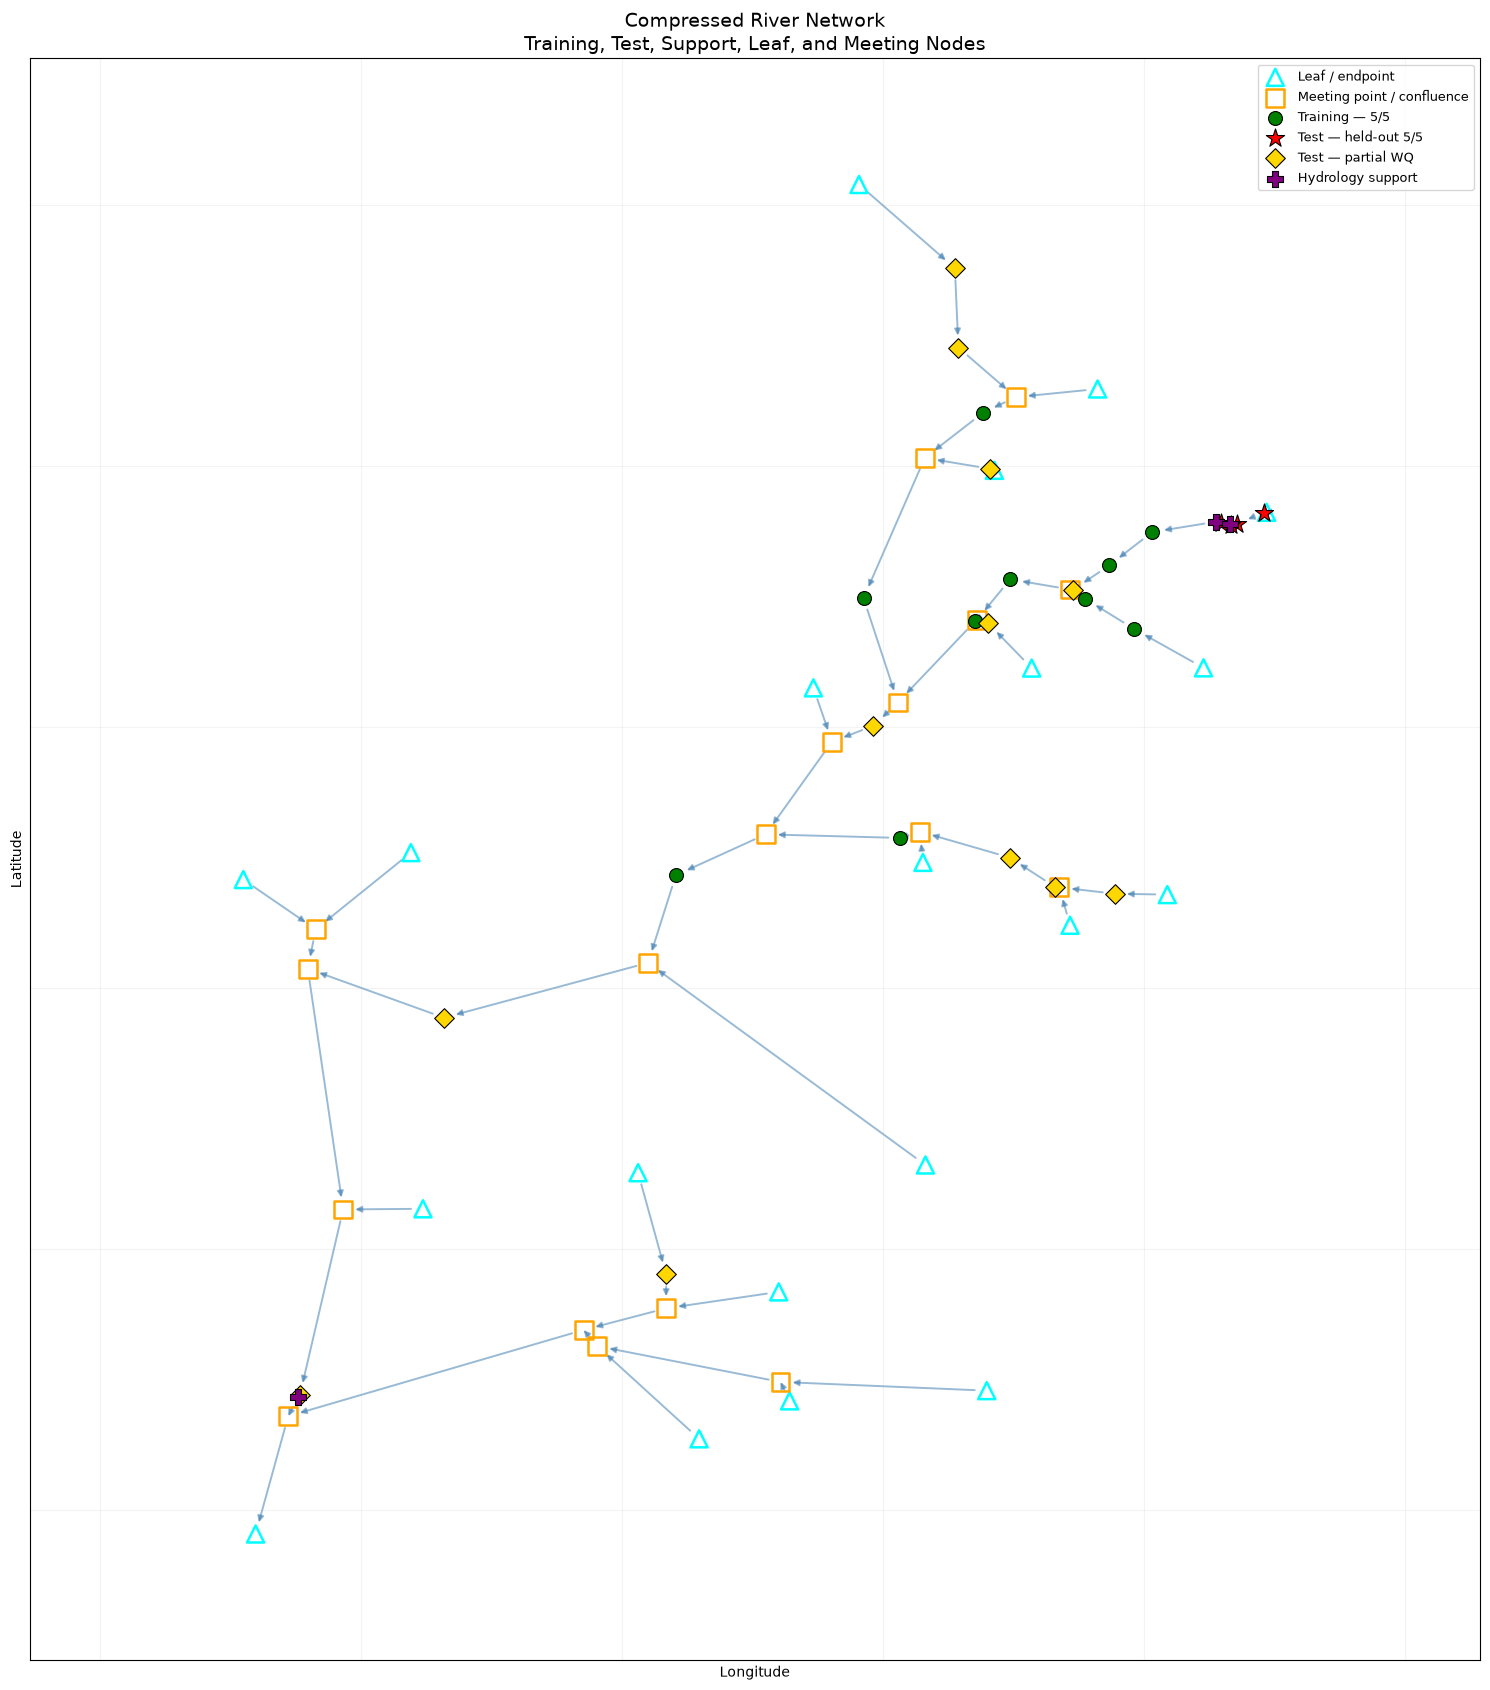

In [98]:
plt.figure(
    figsize=(15, 17)
)


# ==================================================
# RIVER EDGES
# ==================================================

nx.draw_networkx_edges(
    G_plot,
    pos,
    width=1.4,
    alpha=0.55,
    arrows=True,
    arrowsize=9,
    edge_color="steelblue"
)


# ==================================================
# ORDINARY RETAINED NODES
# ==================================================

ordinary_nodes = (
    other_nodes
    - train_nodes
    - full_test_nodes
    - partial_test_nodes
    - support_nodes
)

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(ordinary_nodes),
    node_size=18,
    node_shape="o",
    node_color="gray",
    alpha=0.55,
    label="Other retained nodes"
)


# ==================================================
# LEAF NODES
# Draw as large hollow triangles.
# Stations can then be drawn on top.
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(leaf_nodes),
    node_size=150,
    node_shape="^",
    node_color="none",
    edgecolors="cyan",
    linewidths=1.8,
    label="Leaf / endpoint"
)


# ==================================================
# MEETING POINTS
# Draw as large hollow squares.
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(meeting_nodes),
    node_size=165,
    node_shape="s",
    node_color="none",
    edgecolors="orange",
    linewidths=1.8,
    label="Meeting point / confluence"
)


# ==================================================
# TRAINING — COMPLETE 5/5
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(train_nodes),
    node_size=100,
    node_shape="o",
    node_color="green",
    edgecolors="black",
    linewidths=0.8,
    label="Training — 5/5"
)


# ==================================================
# HELD-OUT COMPLETE TEST
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(full_test_nodes),
    node_size=190,
    node_shape="*",
    node_color="red",
    edgecolors="black",
    linewidths=0.8,
    label="Test — held-out 5/5"
)


# ==================================================
# PARTIAL WQ TEST
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(partial_test_nodes),
    node_size=100,
    node_shape="D",
    node_color="gold",
    edgecolors="black",
    linewidths=0.8,
    label="Test — partial WQ"
)


# ==================================================
# HYDROLOGY SUPPORT
# ==================================================

nx.draw_networkx_nodes(
    G_plot,
    pos,
    nodelist=list(support_nodes),
    node_size=125,
    node_shape="P",
    node_color="purple",
    edgecolors="black",
    linewidths=0.8,
    label="Hydrology support"
)


# ==================================================
# FINAL GRAPH SETTINGS
# ==================================================

plt.title(
    "Compressed River Network\n"
    "Training, Test, Support, Leaf, and Meeting Nodes",
    fontsize=14
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(
    loc="best",
    fontsize=9
)

plt.grid(
    alpha=0.15
)

plt.axis("equal")

plt.tight_layout()

plt.show()

In [99]:
headwater_nodes = set()
outlet_nodes = set()
meeting_nodes = set()
other_nodes = set()

for node in G_master_compressed.nodes():

    indeg = G_master_compressed.in_degree(node)
    outdeg = G_master_compressed.out_degree(node)

    # Upstream beginning of a river
    if indeg == 0 and outdeg > 0:
        headwater_nodes.add(node)

    # Downstream end of the modeled network
    elif indeg > 0 and outdeg == 0:
        outlet_nodes.add(node)

    # Confluence / branching structure
    elif indeg + outdeg >= 3:
        meeting_nodes.add(node)

    else:
        other_nodes.add(node)


print("Headwaters:", len(headwater_nodes))
print("Outlets:", len(outlet_nodes))
print("Meeting points:", len(meeting_nodes))
print("Other nodes:", len(other_nodes))

Headwaters: 19
Outlets: 1
Meeting points: 18
Other nodes: 29


In [100]:
monitored_headwaters = []
unmonitored_headwaters = []

for node in headwater_nodes:

    data = G_master_compressed.nodes[node]

    monitored = (
        data.get("usgs_station_count", 0) > 0
        or
        data.get("support_gauge_count", 0) > 0
    )

    if monitored:
        monitored_headwaters.append(node)
    else:
        unmonitored_headwaters.append(node)


print(
    "Monitored headwaters:",
    len(monitored_headwaters)
)

print(
    "Unmonitored headwaters:",
    len(unmonitored_headwaters)
)

Monitored headwaters: 0
Unmonitored headwaters: 19


In [101]:
source_nodes = {
    node
    for node in G_master_compressed.nodes()
    if (
        G_master_compressed.in_degree(node) == 0
        and
        G_master_compressed.out_degree(node) > 0
    )
}

print("Network source nodes:", len(source_nodes))

Network source nodes: 19


In [102]:
measurement_nodes = {
    node
    for node, data
    in G_master_compressed.nodes(data=True)
    if (
        data.get("usgs_station_count", 0) > 0
        or
        data.get("support_gauge_count", 0) > 0
    )
}

source_coverage = []

for source in source_nodes:

    lengths = nx.single_source_dijkstra_path_length(
        G_master_compressed,
        source,
        weight="length_m"
    )

    reachable_measurements = {
        node: distance
        for node, distance
        in lengths.items()
        if node in measurement_nodes
    }

    if reachable_measurements:

        nearest_node = min(
            reachable_measurements,
            key=reachable_measurements.get
        )

        nearest_distance_km = (
            reachable_measurements[
                nearest_node
            ] / 1000
        )

    else:

        nearest_node = None
        nearest_distance_km = None

    source_coverage.append({
        "source_node": source,
        "nearest_measurement_node":
            nearest_node,
        "distance_to_first_measurement_km":
            nearest_distance_km
    })


source_coverage = pd.DataFrame(
    source_coverage
)

display(
    source_coverage.sort_values(
        "distance_to_first_measurement_km",
        ascending=False,
        na_position="first"
    )
)

,source_node,nearest_measurement_node,distance_to_first_measurement_km
5,188990639,NaN,NaN
11,209256258,NaN,NaN
13,202613460,NaN,NaN
16,204021741,NaN,NaN
0,128398218,203177183.0,729.734489
18,171485821,151170041.0,711.542365
10,132116925,203177183.0,673.670218
1,105675404,131520862.0,370.704374
12,177526604,203177183.0,328.067555
14,64455269,67739434.0,159.991380


In [103]:
print(
    source_coverage[
        "distance_to_first_measurement_km"
    ].describe()
)

count     15.000000
mean     243.585014
std      260.233127
min        1.910262
25%       70.286115
50%      142.879136
75%      349.385965
max      729.734489
Name: distance_to_first_measurement_km, dtype: float64


In [ ]:
for node in source_nodes:

    G_master_compressed.nodes[
        node
    ]["river_role"] = "network_source"

    G_master_compressed.nodes[
        node
    ]["has_wq_observation"] = False

    G_master_compressed.nodes[
        node
    ]["is_boundary_node"] = True
    


In [105]:
COVERAGE_THRESHOLD_KM = 100

def source_category(distance):

    if pd.isna(distance):
        return "no downstream measurement"

    elif distance <= COVERAGE_THRESHOLD_KM:
        return "covered"

    else:
        return "long unmonitored reach"


source_coverage["coverage_class"] = (
    source_coverage[
        "distance_to_first_measurement_km"
    ].apply(source_category)
)

print(
    source_coverage[
        "coverage_class"
    ].value_counts()
)

display(
    source_coverage.sort_values(
        "distance_to_first_measurement_km",
        ascending=False,
        na_position="first"
    )
)

coverage_class
long unmonitored reach       8
covered                      7
no downstream measurement    4
Name: count, dtype: int64


,source_node,nearest_measurement_node,distance_to_first_measurement_km,coverage_class
5,188990639,NaN,NaN,no downstream measurement
11,209256258,NaN,NaN,no downstream measurement
13,202613460,NaN,NaN,no downstream measurement
16,204021741,NaN,NaN,no downstream measurement
0,128398218,203177183.0,729.734489,long unmonitored reach
18,171485821,151170041.0,711.542365,long unmonitored reach
10,132116925,203177183.0,673.670218,long unmonitored reach
1,105675404,131520862.0,370.704374,long unmonitored reach
12,177526604,203177183.0,328.067555,long unmonitored reach
14,64455269,67739434.0,159.991380,long unmonitored reach


In [106]:
unmeasured_sources = (
    source_coverage.loc[
        source_coverage[
            "nearest_measurement_node"
        ].isna(),
        "source_node"
    ]
    .astype(int)
    .tolist()
)

print(
    "Completely unmeasured sources:",
    unmeasured_sources
)

Completely unmeasured sources: [188990639, 209256258, 202613460, 204021741]


In [107]:
def trace_downstream_until_stop(
    G,
    source
):

    reachable = nx.descendants(
        G,
        source
    )

    reachable.add(source)

    return reachable


for source in unmeasured_sources:

    branch_nodes = (
        trace_downstream_until_stop(
            G_master_compressed,
            source
        )
    )

    print(
        "\nSource:",
        source
    )

    print(
        "Reachable nodes:",
        len(branch_nodes)
    )

    measurements = [
        n
        for n in branch_nodes
        if (
            G_master_compressed.nodes[n]
            .get("usgs_station_count", 0) > 0

            or

            G_master_compressed.nodes[n]
            .get("support_gauge_count", 0) > 0
        )
    ]

    print(
        "Reachable measurements:",
        len(measurements)
    )


Source: 188990639
Reachable nodes: 5
Reachable measurements: 0

Source: 209256258
Reachable nodes: 5
Reachable measurements: 0

Source: 202613460
Reachable nodes: 6
Reachable measurements: 0

Source: 204021741
Reachable nodes: 6
Reachable measurements: 0
